<a href="https://colab.research.google.com/github/rowanmacy/text-classifier/blob/main/Problem_2_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install optunahub and optuna
!pip install optunahub optuna cmaes scipy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.7 MB/s eta 0:00:00


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import os
import textwrap

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold,GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score

from scipy.stats import uniform

import optuna
import optunahub

from sklearn.model_selection import GroupShuffleSplit

In [ ]:
# TODOs

In [5]:
# Clone repo
!rm -rf /content/text-classifier  # clear any existing clone
!git clone "https://github.com/rowanmacy/text-classifier/"  # clone repo

Cloning into 'text-classifier'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 107 (delta 38), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 31.66 MiB | 22.85 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [6]:
# Check repo contents
!ls /content/text-classifier/starter_code/data_readinglevel/

x_test_BERT_embeddings.npz  x_train_BERT_embeddings.npz  y_train.csv
x_test.csv		    x_train.csv


## Read in data

In [7]:
# Read in training data
x_dev = np.array(np.load("/content/text-classifier/starter_code/data_readinglevel/x_train_BERT_embeddings.npz")['arr_0'])
x_df = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/x_train.csv")
y_dev = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/y_train.csv")
x_test  = np.array(np.load("/content/text-classifier/starter_code/data_readinglevel/x_test_BERT_embeddings.npz")['arr_0'])

In [8]:
# Convert coarse label into binary classification
y_dev['Class'] = (y_dev['Coarse Label'] == 'Key Stage 4-5').astype(int)
y_dev = y_dev['Class']

In [9]:
# Generate groups of unique combinations of author and title for grouping of CV splits later
author_title_combos = x_df[['author', 'title']].drop_duplicates()
author_title_combos['group'] = range(0, len(author_title_combos))

x_train_groupings = pd.merge(x_df, author_title_combos, on=['author', 'title'], how='left')

# Extract groups
groups = x_train_groupings['group'].values

## Pre-defined split for proxy test set (validation)

In [10]:
# TODO MAKE SURE NO AUTHOR OVERLAP
# Split using GroupShuffleSplit
split = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
split.get_n_splits()

# Capture training and validation indices
train_idx, val_idx = next(split.split(x_dev, y_dev, groups))

# Separate training and validation sets
X_train = x_dev[train_idx]
X_val = x_dev[val_idx]
y_train = y_dev.iloc[train_idx]
y_val = y_dev.iloc[val_idx]

# Capture groupings in training and validation sets
train_groups = groups[train_idx]
val_groups = groups[val_idx]

# Determine if there are any overlapping groups
shared_groups = list(set(train_groups) & set(val_groups))
print(shared_groups)

[]


In [11]:
# Set up objective function for Optuna
def objective(trial):
  # Suggest values for hyperparameters
  C = trial.suggest_float('C', 10e-4, 10e0, log=True)
  solver = trial.suggest_categorical('solver', ['saga', 'liblinear'])
  penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

  # Set up pipeline
  model = Pipeline([
     ('problem_2_model', LogisticRegression(max_iter=1500, random_state=101, penalty=penalty, C=C, solver=solver)),
  ])

  # Perform cross-validation and calculate AUROC
  group_k_fold = GroupKFold(n_splits=5)
  score = cross_val_score(model, X_train, y_train, groups=train_groups, cv=group_k_fold, scoring='roc_auc').mean()

  return score

In [12]:
# Load autosampler
module = optunahub.load_module(package="samplers/auto_sampler")

In [ ]:
# Create and run study
study = optuna.create_study(direction='maximize', sampler=module.AutoSampler())
study.optimize(objective, n_trials=50)

[I 2026-03-02 16:32:25,058] A new study created in memory with name: no-name-87239a9c-c22e-4527-b715-3f38aa1da56e
[I 2026-03-02 16:32:51,767] Trial 0 finished with value: 0.7651340364155191 and parameters: {'C': 0.24692950434016459, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 0 with value: 0.7651340364155191.
/root/.cache/optunahub/github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:138: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  return TPESampler(
/root/.cache/optunahub/github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:138: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  return TPESampler(
[I 2026-03-02 16:33:32,894] Trial 1 finished with value: 0.7342373454847662 and parameters: {'C': 0.0069866888712530155, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with val

In [3]:
# Extract parameters from best trial
trial = study.best_trial
hyperparameters = trial.params

for param, value in hyperparameters.items():
  print(f'{param}:', value)

print('\nBest score:', round(study.best_value,3))

NameError: name 'study' is not defined

In [ ]:
# Train model with best performing hyperparameters on development set
model = Pipeline([
     ('problem_1_model', LogisticRegression(max_iter=500, random_state=101, penalty=hyperparameters['penalty'], C=hyperparameters['C'])),
  ])

model.fit(x_dev, y_dev)

Pipeline(steps=[('problem_1_model',
                 LogisticRegression(C=0.002801152792828191, max_iter=500,
                                    random_state=101))])

In [ ]:
# Evaluate performance on training and validation data
yhat_tr = model.predict_proba(X_train)[:,1]
yhat_val = model.predict_proba(X_val)[:,1]

# Calculate AUROC for training and validation predictions
roc_auc_tr = roc_auc_score(y_train, yhat_tr)
roc_auc_val = roc_auc_score(y_val, yhat_val)
print('Training score:', round(roc_auc_tr, 3))
print('Validation score:', round(roc_auc_val, 3))

Training score: 0.812
Validation score: 0.757


In [ ]:
# Compute and store predictions on test data
yhat_test = model.predict_proba(x_test)

# Delete previous file
# os.remove('yproba1_test.txt')

# # Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(str(v) for v in yhat_test[:, 1]))

## Set up pipeline

In [ ]:
# Define pipeline for preprocessing and classifier
problem_1_pipeline = Pipeline([
     ('problem_2_model', LogisticRegression(max_iter=1500, random_state=101, penalty='l1')),
])

## Create RandomizedSearchCV

In [ ]:
# Define hyperparameter grid to search and scoring metric
distributions = dict()

# Model parameters
distributions['problem_2_model__C'] = np.logspace(-6, 6, 1000)
distributions['problem_2_model__solver'] = ['lbfgs', 'saga', 'liblinear']
distributions['problem_2_model__penalty'] = ['l1', 'l2']

# Preprocessor parameters
scoring_metric = 'roc_auc'

In [ ]:
# Define RandomizedSearchCV and fit to training data
random_searcher = RandomizedSearchCV(
    problem_1_pipeline,
    distributions,
    n_iter=10,  # increases number of parameter combinations tried
    scoring=scoring_metric,
    cv=KFold(n_splits=5, shuffle=True), # Always good to shuffle
    refit=True, # Automatically retrain the best-performing model on all available data
    verbose = 1,
    random_state=101,
    error_score = 'raise')

In [ ]:
# Fit random_searcher object to training data
random_searcher.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('problem_2_model',
                                              LogisticRegression(max_iter=1500,
                                                                 penalty='l1',
                                                                 random_state=101))]),
                   param_distributions={'problem_2_model__C': array([1.00000000e-06, 1.02804473e-06, 1.05687597e-06, 1.08651577e-06,
       1.11698682e-06, 1.14831241e-06, 1.180516...
       6.60419396e+05, 6.78940681e+05, 6.97981391e+05, 7.17556092e+05,
       7.37679760e+05, 7.58367791e+05, 7.79636013e+05, 8.01500696e+05,
       8.23978568e+05, 8.47086827e+05, 8.70843150e+05, 8.95265713e+05,
       9.20373200e+05, 9.46184819e+05, 9.72720319e+05, 1.00000000e+06]),
                                        'problem_2_model__penalty': ['l1',
                                                                     'l2'],
                                        'problem_2_model__solver': ['lbfgs',
                                                                    'saga',
                                                                    'liblinear']},
                   random_state=101, scoring='roc_auc', verbose=1)

In [ ]:
# Print result of search
problem_1_hyp_results = pd.DataFrame(random_searcher.cv_results_).copy()
param_keys = ['param_'+str(key) for key in random_searcher.best_params_.keys()]

# Rearrange row order
problem_1_hyp_results.sort_values(param_keys, inplace=True)

# Visualize
problem_1_hyp_results[param_keys + ['mean_test_score', 'rank_test_score']]

,param_problem_2_model__solver,param_problem_2_model__penalty,param_problem_2_model__C,mean_test_score,rank_test_score
0,lbfgs,l2,8354.528058,0.740386,9
8,liblinear,l1,224569.799554,0.740815,8
4,liblinear,l2,0.000015,0.759370,3
2,liblinear,l2,0.000518,0.776241,2
1,liblinear,l2,0.001222,0.781342,1
6,liblinear,l2,143.270295,0.741339,7
7,saga,l1,0.000088,0.500000,10
5,saga,l1,223.022330,0.741847,4
3,saga,l1,250841.505928,0.741563,5
9,saga,l2,340041.193270,0.741563,5


In [ ]:
# Capture best hyperparameters
problem_1_params = random_searcher.best_params_

for param, value in problem_1_params.items():
  print(param, ':', value)

problem_2_model__solver : liblinear
problem_2_model__penalty : l2
problem_2_model__C : 0.0012220446866314887


## Make predictions and plot ROC curve

In [ ]:
# Evaluate performance on training and validation data
yhat_tr = random_searcher.predict_proba(X_train)[:,1]
yhat_val = random_searcher.predict_proba(X_val)[:,1]

# Calculate AUROC for training and validation predictions
roc_auc_tr = roc_auc_score(y_train, yhat_tr)
roc_auc_val = roc_auc_score(y_val, yhat_val)
print('Training score:', round(roc_auc_tr, 3))
print('Validation score:', round(roc_auc_val, 3))

NameError: name 'random_searcher' is not defined

In [ ]:
# Print confusion matrices at 50% threshold
print('Training CF:\n', confusion_matrix(y_train, yhat_tr >= 0.5))
print('\nValidation CF:\n', confusion_matrix(y_val, yhat_val >= 0.5))

Training CF:
 [[1548  571]
 [ 630 1892]]

Validation CF:
 [[230 160]
 [151 375]]


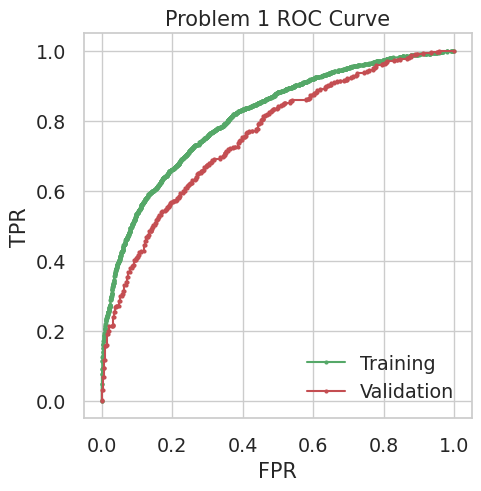

In [ ]:
# Print ROC curves
tr_fpr, tr_tpr, tr_thresholds = roc_curve(y_train, yhat_tr)
val_fpr, val_tpr, val_thresholds = roc_curve(y_val, yhat_val)

plt.figure(figsize=(5,5))
plt.plot(tr_fpr, tr_tpr, 'g.-', label='Training')
plt.plot(val_fpr, val_tpr, 'r.-', label='Validation')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Problem 1 ROC Curve')
plt.legend(loc='lower right')

## Save results to file

In [ ]:
# Save parameters to text file
file = open('parameter_iterations.txt', "x")

with open('parameter_iterations.txt', "a") as f:
  for param, value in hyperparameters.items():
    f.write('\n' + str(param) + ': ' + str(value))
  f.write('\n\nTraining score: ' + str(round(roc_auc_tr, 3)))
  f.write('\nValidation Score: ' + str(round(roc_auc_val, 3)))
  f.write('\n\n')

In [ ]:
# Make predictions on test data
yhat_test = model.predict_proba(x_test)

In [1]:
# Delete previous file
#os.remove('yproba1_test.txt')

# # Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(str(v) for v in yhat_test[:, 1]))

NameError: name 'yhat_test' is not defined

## Compare predictions to true labels for training data

In [63]:
# Extract parameters from best trial
# [I 2026-03-02 17:09:27,998] Trial 22 finished with value: 0.7710803353206168 and parameters: {'C': 0.002801152792828191, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 22 with value: 0.7710803353206168.

# Train model with best performing hyperparameters on development set
model = Pipeline([
     ('problem_1_model', LogisticRegression(max_iter=500, random_state=101, penalty='l2', C=0.002801152792828191)),
  ])

model.fit(X_train, y_train)

# Evaluate performance on training and validation data
yhat_val = model.predict_proba(X_val)[:,1]

# Determine difference between prediction and
y_val_reset = np.array(y_val)  # convert to numpy to drop pandas index

yhat_diff = abs(y_val_reset - yhat_val)
# print(yhat_diff)
print("indices")
print(np.argsort(yhat_diff)[-5:]) # five values closest to 1 are 5 most confidently wrong, 5 values closest to 0 are most confidently right

for i in range(1, 4):
    idx = np.argsort(yhat_diff)[-i]
    original_idx = val_idx[idx]
    print(f"{i}th most confidently wrong index: {idx}\n")
    print(f"y = {y_val_reset[idx]}, yhat = {yhat_val[idx]} \n")
    print(f"Author: {x_df.iloc[original_idx]['author']}, \n Title: {x_df.iloc[original_idx]['title']}, \n Text: {x_df.iloc[original_idx]['text']} \n")

for i in range(1, 4):
    idx = np.argsort(yhat_diff)[i]
    original_idx = val_idx[idx]
    print(f"{i}th most confidently right index: {idx}\n")
    print(f"y = {y_val_reset[idx]}, yhat = {yhat_val[idx]} \n")
    print(f"Author: {x_df.iloc[original_idx]['author']}, \n Title: {x_df.iloc[original_idx]['title']}, \n Text: {x_df.iloc[original_idx]['text']} \n")


indices
[556 681 587 796 607]
1th most confidently wrong index: 607

y = 0, yhat = 0.9210151094053247 

Author: Jr. Horatio Alger, 
 Title: Phil, the Fiddler, 
 Text: Knowing what I do of his fierce temper, I should  not be surprised to hear of a murderous encounter between him and his  nephew after his release from imprisonment, unless, as is probable, just  before the release, Pietro should flee the country with the ill-gotten  gains he may have acquired during his term of office. Meanwhile the boys  are treated with scarcely less rigor by him than by his uncle, and toil  early and late, suffering hardships and privations, that Pietro may grow  rich. 

2th most confidently wrong index: 796

y = 0, yhat = 0.8935322207178232 

Author: Robert Louis Stevenson, 
 Title: Kidnapped, 
 Text: Altogether, I had a fair chance to see some of the inner  workings of a Highland clan; and this with a proscribed, fugitive chief;  his country conquered; the troops riding upon all sides in quest of  hi